# Airbridges

Airbridges are ground-plane crossovers that hop *over* a CPW trace to tie
the ground plane together and suppress unwanted slotline modes. In Quantum
Metal an airbridge is a first-class `QComponent`: its geometry lives in the
design, so it shows up in `qm.view` and is exported by every renderer — no
GDS-only special case.

This tutorial covers the `Airbridge` component, automatic placement along a
routed CPW with `route_airbridges`, and GDS export.

## Setup

In [1]:
import qiskit_metal as qm
from qiskit_metal import designs, Dict
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.airbridge import Airbridge, route_airbridges

## Preview

Here is where we are headed: a meander CPW with airbridges auto-placed along
every straight **and** every bend. The rest of the tutorial builds up to this
one piece at a time.

05:41AM 03s INFO [_start_renderers]: Renderer=hfss skipped: runtime dependency not installed (QAnsysRenderer requires pyEPR. Install with: pip install 'quantum-metal[ansys]').


05:41AM 03s INFO [_start_renderers]: Renderer=q3d skipped: runtime dependency not installed (QAnsysRenderer requires pyEPR. Install with: pip install 'quantum-metal[ansys]').


05:41AM 03s INFO [_start_renderers]: Renderer=aedt_q3d skipped: runtime dependency not installed (QPyaedt requires pyaedt (ansys.aedt.core). Install with: pip install 'quantum-metal[ansys]').


05:41AM 03s INFO [_start_renderers]: Renderer=aedt_hfss skipped: runtime dependency not installed (QPyaedt requires pyaedt (ansys.aedt.core). Install with: pip install 'quantum-metal[ansys]').


05:41AM 03s WARNING [check_lengths]: For path table, component=cpw, key=trace has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


05:41AM 03s WARNING [check_lengths]: For path table, component=cpw, key=cut has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


05:41AM 03s WARNING [check_lengths]: For path table, component=cpw, key=trace has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


05:41AM 03s WARNING [check_lengths]: For path table, component=cpw, key=cut has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


05:41AM 03s WARNING [check_lengths]: For path table, component=cpw, key=trace has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


05:41AM 03s WARNING [check_lengths]: For path table, component=cpw, key=cut has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


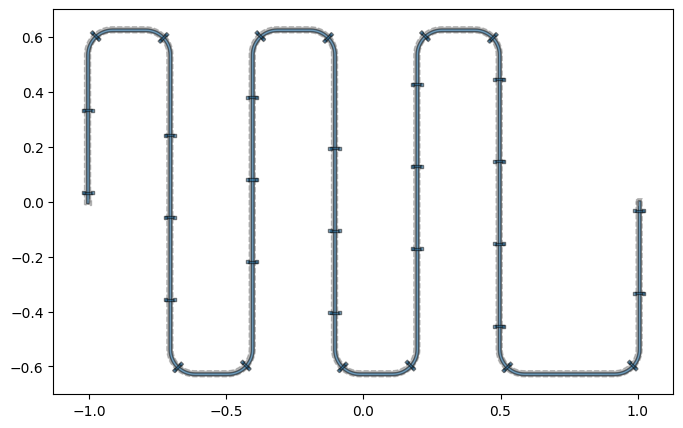

In [2]:
design = designs.DesignPlanar()
design.overwrite_enabled = True

OpenToGround(design, "A", options=dict(pos_x="-1mm", orientation="0"))
OpenToGround(design, "B", options=dict(pos_x="1mm", orientation="180"))
cpw = RouteMeander(
    design,
    "cpw",
    options=Dict(
        pin_inputs=Dict(
            start_pin=Dict(component="A", pin="open"),
            end_pin=Dict(component="B", pin="open"),
        ),
        total_length="9mm",
        fillet="90um",
        trace_width="10um",
        trace_gap="6um",
        meander=Dict(spacing="0.3mm"),
    ),
)
design.rebuild()

route_airbridges(design, cpw, pitch="0.3mm", min_spacing="30um", bridge_at_corners=True)
design.rebuild()
qm.view(design)

## A single airbridge

The `Airbridge` component draws two base-metal landing pads joined by an
elevated bridge span. The bridge and the pads are emitted on separate layers
(`bridge_layer` / `pad_layer`) so the two-step fabrication is representable.

05:41AM 04s INFO [_start_renderers]: Renderer=hfss skipped: runtime dependency not installed (QAnsysRenderer requires pyEPR. Install with: pip install 'quantum-metal[ansys]').


05:41AM 04s INFO [_start_renderers]: Renderer=q3d skipped: runtime dependency not installed (QAnsysRenderer requires pyEPR. Install with: pip install 'quantum-metal[ansys]').


05:41AM 04s INFO [_start_renderers]: Renderer=aedt_q3d skipped: runtime dependency not installed (QPyaedt requires pyaedt (ansys.aedt.core). Install with: pip install 'quantum-metal[ansys]').


05:41AM 04s INFO [_start_renderers]: Renderer=aedt_hfss skipped: runtime dependency not installed (QPyaedt requires pyaedt (ansys.aedt.core). Install with: pip install 'quantum-metal[ansys]').


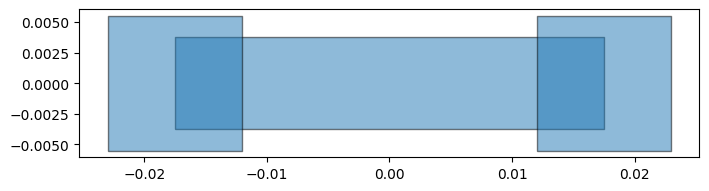

In [3]:
design = designs.DesignPlanar()
design.overwrite_enabled = True

Airbridge(design, "ab", options=dict(crossover_length="24um"))
design.rebuild()
qm.view(design)

Key options (all parseable strings, e.g. `'22um'`):

- `crossover_length` — the gap the bridge spans, foot-to-foot. Size it to
  about `cpw_width + 2*cpw_gap` of the CPW you are crossing.
- `bridge_width` — width of the elevated span.
- `pad_width`, `pad_length` — the base landing-pad footprint.
- `bridge_layer`, `pad_layer` — the fabrication layers.

## Auto-placing airbridges along a CPW

`route_airbridges(design, route, ...)` adds `Airbridge` components along a
routed CPW. Placement follows the route's *filleted* centerline (the geometry
that is actually rendered), so every bridge sits on the trace and crosses it
perpendicular to the local direction — through bends as well as straights.
Bridges are spaced by `pitch` and kept `min_spacing` clear of the end pins.
By default each span is sized to the route's `trace_width + 2*trace_gap`.

05:41AM 04s INFO [_start_renderers]: Renderer=hfss skipped: runtime dependency not installed (QAnsysRenderer requires pyEPR. Install with: pip install 'quantum-metal[ansys]').


05:41AM 04s INFO [_start_renderers]: Renderer=q3d skipped: runtime dependency not installed (QAnsysRenderer requires pyEPR. Install with: pip install 'quantum-metal[ansys]').


05:41AM 04s INFO [_start_renderers]: Renderer=aedt_q3d skipped: runtime dependency not installed (QPyaedt requires pyaedt (ansys.aedt.core). Install with: pip install 'quantum-metal[ansys]').


05:41AM 04s INFO [_start_renderers]: Renderer=aedt_hfss skipped: runtime dependency not installed (QPyaedt requires pyaedt (ansys.aedt.core). Install with: pip install 'quantum-metal[ansys]').


05:41AM 04s WARNING [check_lengths]: For path table, component=cpw, key=trace has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


...

05:41AM 04s WARNING [check_lengths]: For path table, component=cpw, key=trace has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


05:41AM 04s WARNING [check_lengths]: For path table, component=cpw, key=cut has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


05:41AM 04s WARNING [check_lengths]: For path table, component=cpw, key=trace has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


05:41AM 04s WARNING [check_lengths]: For path table, component=cpw, key=cut has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


placed 27 airbridges


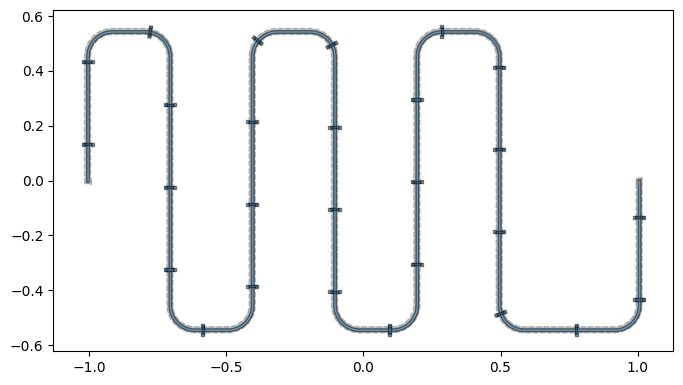

In [4]:
design = designs.DesignPlanar()
design.overwrite_enabled = True

OpenToGround(design, "A", options=dict(pos_x="-1mm", orientation="0"))
OpenToGround(design, "B", options=dict(pos_x="1mm", orientation="180"))

cpw = RouteMeander(
    design,
    "cpw",
    options=Dict(
        pin_inputs=Dict(
            start_pin=Dict(component="A", pin="open"),
            end_pin=Dict(component="B", pin="open"),
        ),
        total_length="8mm",
        fillet="90um",
        trace_width="10um",
        trace_gap="6um",
        meander=Dict(spacing="0.3mm"),
    ),
)
design.rebuild()

bridges = route_airbridges(design, cpw, pitch="0.3mm", min_spacing="30um")
design.rebuild()
print(f"placed {len(bridges)} airbridges")
qm.view(design)

`route_airbridges` is idempotent: re-running it (e.g. re-executing this cell,
or after re-routing) clears the airbridges it previously placed under the same
`name` and re-places them. Tune the spacing, or forward extra options to every
bridge via `ab_options`:

05:41AM 05s WARNING [check_lengths]: For path table, component=cpw, key=trace has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


05:41AM 05s WARNING [check_lengths]: For path table, component=cpw, key=cut has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


placed 17 airbridges


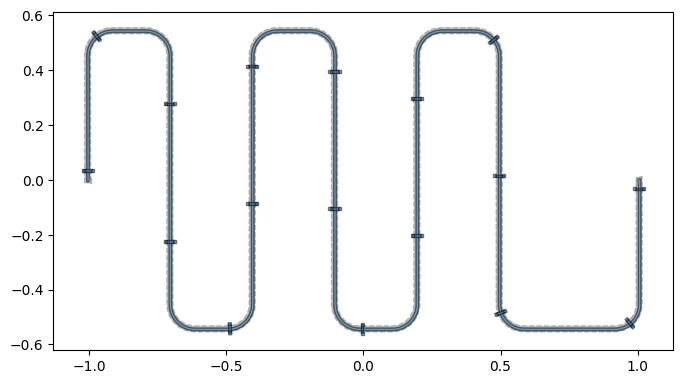

In [5]:
bridges = route_airbridges(
    design, cpw, pitch="0.5mm", min_spacing="30um", ab_options=dict(bridge_width="10um")
)
design.rebuild()
print(f"placed {len(bridges)} airbridges")
qm.view(design)

### Guaranteeing a bridge on every bend

Uniform spacing already covers bends wherever a `pitch` sample happens to land
on a fillet arc, but with a coarse `pitch` a corner can fall between samples.
Set `bridge_at_corners=True` to force one bridge centered on every rounded
bend, in addition to the uniform-pitch bridges. A uniform bridge that would
land within half a pitch of a corner bridge is dropped so the two do not bunch
up.

05:41AM 05s WARNING [check_lengths]: For path table, component=cpw, key=trace has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


05:41AM 05s WARNING [check_lengths]: For path table, component=cpw, key=cut has short segments that could cause issues with fillet. Values in (1-1) (14-14)  are index(es) in shapely geometry.


placed 18 airbridges (one on every bend)


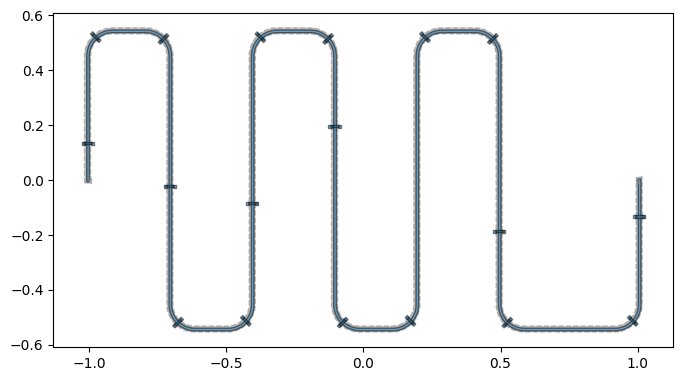

In [6]:
bridges = route_airbridges(
    design, cpw, pitch="0.6mm", min_spacing="30um", bridge_at_corners=True
)
design.rebuild()
print(f"placed {len(bridges)} airbridges (one on every bend)")
qm.view(design)

## Export to GDS

Because airbridges are real components, they export like anything else — the
bridge and pad polygons land on their configured GDS layers. Here we export a
straight CPW with airbridges:

In [7]:
import tempfile
import os

gdesign = designs.DesignPlanar()
gdesign.overwrite_enabled = True
OpenToGround(gdesign, "A", options=dict(pos_x="-0.6mm", orientation="0"))
OpenToGround(gdesign, "B", options=dict(pos_x="0.6mm", orientation="180"))
gcpw = RouteStraight(
    gdesign,
    "cpw",
    options=Dict(
        pin_inputs=Dict(
            start_pin=Dict(component="A", pin="open"),
            end_pin=Dict(component="B", pin="open"),
        ),
        trace_width="10um",
        trace_gap="6um",
    ),
)
gdesign.rebuild()
route_airbridges(gdesign, gcpw, pitch="0.2mm", min_spacing="30um")
gdesign.rebuild()

path = os.path.join(tempfile.mkdtemp(), "airbridge_demo.gds")
gdesign.renderers.gds.export_to_gds(path)
print("wrote", path)

05:41AM 06s INFO [_start_renderers]: Renderer=hfss skipped: runtime dependency not installed (QAnsysRenderer requires pyEPR. Install with: pip install 'quantum-metal[ansys]').


05:41AM 06s INFO [_start_renderers]: Renderer=q3d skipped: runtime dependency not installed (QAnsysRenderer requires pyEPR. Install with: pip install 'quantum-metal[ansys]').


05:41AM 06s INFO [_start_renderers]: Renderer=aedt_q3d skipped: runtime dependency not installed (QPyaedt requires pyaedt (ansys.aedt.core). Install with: pip install 'quantum-metal[ansys]').


05:41AM 06s INFO [_start_renderers]: Renderer=aedt_hfss skipped: runtime dependency not installed (QPyaedt requires pyaedt (ansys.aedt.core). Install with: pip install 'quantum-metal[ansys]').


05:41AM 06s WARNING [import_junction_gds_file]: Not able to find file:"../resources/Fake_Junctions.GDS".  Not used to replace junction. Checked directory:"/home/user/qiskit-metal/tutorials/2 From components to chip/resources".


05:41AM 06s WARNING [_check_either_cheese]: layer=30 is not in chip=main either in no_cheese_view_in_file or cheese_view_in_file from self.options.


05:41AM 06s WARNING [_check_either_cheese]: layer=31 is not in chip=main either in no_cheese_view_in_file or cheese_view_in_file from self.options.


wrote /tmp/tmp963uolnm/airbridge_demo.gds


### Viewing the exported GDS

Let's load the file back with `gdstk` and draw it. The airbridge span and pads
are read straight from the GDS layers; the CPW ground/trace/gap is
reconstructed from the design's own clearance geometry, because a fabrication
ground plane is a solid metal pour — a flat fill of the raw GDS would hide the
thin CPW gap. Layers are colored with a legend.

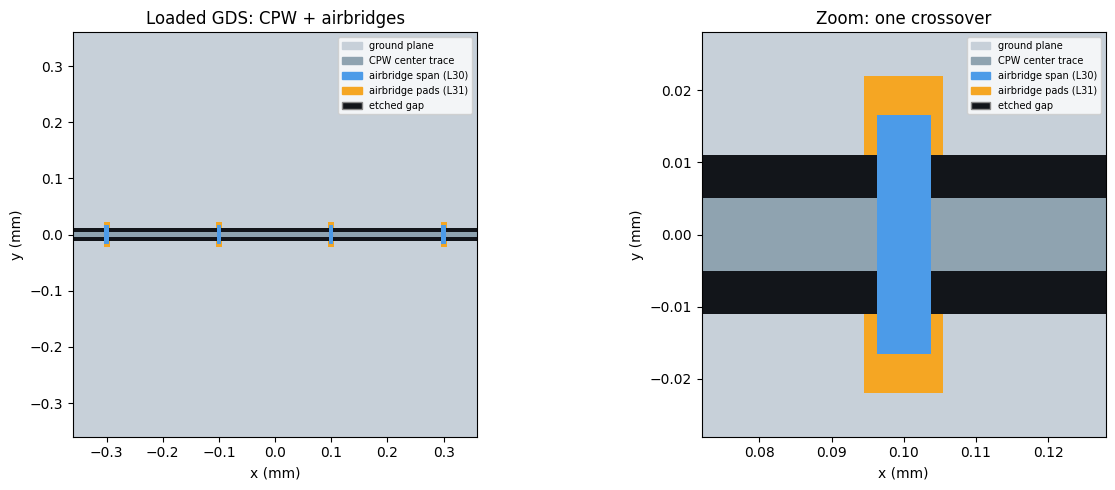

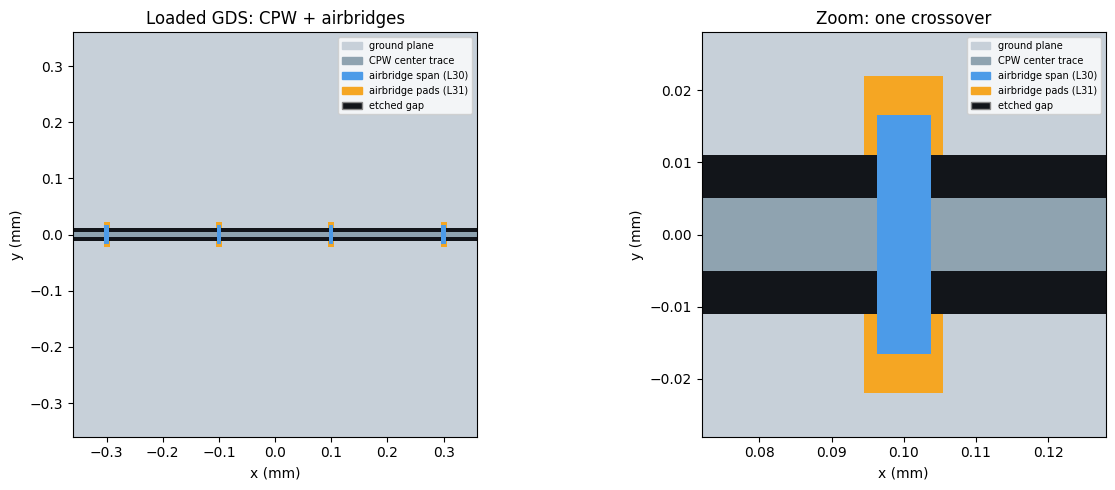

In [8]:
import gdstk
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Patch
from shapely.geometry import Polygon as SPoly, box
from shapely.ops import unary_union


def show_airbridge_gds(
    design, gds_path, center_mm, span_mm, ax, bridge_layer=30, pad_layer=31
):
    """Load an exported GDS and draw it CPW-correctly, colored + legend.

    Airbridge polygons come straight from the loaded GDS (``bridge_layer`` /
    ``pad_layer``); the CPW ground/trace/gap is reconstructed from the design's
    ``subtract`` QGeometry so the thin gap is visible against the solid ground.
    """
    lib = gdstk.read_gds(gds_path)
    top = next((c for c in lib.cells if c.name == "TOP"), lib.cells[0])

    def gds_union(layer):
        ps = [
            SPoly(p.points).buffer(0)
            for p in top.get_polygons(depth=None)
            if p.layer == layer
        ]
        return unary_union(ps) if ps else None

    def buf(row):
        g = row.geometry
        if row.get("width", 0) and g.geom_type in ("LineString", "MultiLineString"):
            return g.buffer(
                design.parse_value(row.width) / 2.0, cap_style=2, join_style=2
            )
        return g

    sx = design.parse_value(design.chips.main.size.size_x)
    sy = design.parse_value(design.chips.main.size.size_y)
    pt, po = design.qgeometry.tables["path"], design.qgeometry.tables["poly"]
    gaps = unary_union(
        [buf(r) for _, r in pt.iterrows() if r["subtract"]]
        + [buf(r) for _, r in po.iterrows() if r["subtract"]]
    )
    metal = box(-sx / 2, -sy / 2, sx / 2, sy / 2).difference(gaps)
    trace = unary_union([buf(r) for _, r in pt.iterrows() if not r["subtract"]])
    bridge, pads = gds_union(bridge_layer), gds_union(pad_layer)

    def draw(geom, color):
        if geom is None or geom.is_empty:
            return
        for g in [geom] if geom.geom_type == "Polygon" else geom.geoms:
            v = list(g.exterior.coords)
            c = [Path.MOVETO] + [Path.LINETO] * (len(v) - 2) + [Path.CLOSEPOLY]
            for r in g.interiors:
                rv = list(r.coords)
                v += rv
                c += [Path.MOVETO] + [Path.LINETO] * (len(rv) - 2) + [Path.CLOSEPOLY]
            ax.add_patch(PathPatch(Path(v, c), facecolor=color, edgecolor="none"))

    ground, tr, br, pa, sub = "#C7D0D9", "#8FA3B0", "#4C9BE8", "#F5A623", "#12151a"
    ax.set_facecolor(sub)
    for geom, col in [(metal, ground), (trace, tr), (pads, pa), (bridge, br)]:
        draw(geom, col)
    cx, cy = center_mm
    ax.set_xlim(cx - span_mm, cx + span_mm)
    ax.set_ylim(cy - span_mm, cy + span_mm)
    ax.set_aspect("equal")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.legend(
        handles=[
            Patch(color=ground, label="ground plane"),
            Patch(color=tr, label="CPW center trace"),
            Patch(color=br, label=f"airbridge span (L{bridge_layer})"),
            Patch(color=pa, label=f"airbridge pads (L{pad_layer})"),
            Patch(facecolor=sub, edgecolor="#888", label="etched gap"),
        ],
        fontsize=7,
        loc="upper right",
    )
    return lib


# Center the zoom on one of the placed airbridges.
ab_x = sorted(
    gdesign.parse_value(c.options["pos_x"])
    for n, c in gdesign.components.items()
    if n.startswith("cpw_ab_")
)
zoom_x = ab_x[len(ab_x) // 2]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
show_airbridge_gds(gdesign, path, center_mm=(0.0, 0.0), span_mm=0.36, ax=axes[0])
axes[0].set_title("Loaded GDS: CPW + airbridges")
show_airbridge_gds(gdesign, path, center_mm=(zoom_x, 0.0), span_mm=0.028, ax=axes[1])
axes[1].set_title("Zoom: one crossover")
fig.tight_layout()
fig

## Experimental: 3D airbridges

In a planar view and in GDS the crossover is flat (z = 0). For 3D FEM the
span should be *elevated* above the base metal. Metal's 3D renderers extrude
each layer by the `thickness` / `z_coord` in the design's **layer stack**, so
lifting the `bridge_layer` is all it takes — the same rows feed gmsh, and (as
the ecosystem matures) AWS Palace or Ansys.

To keep the elevated span connected to the base metal (so the design meshes as
one conductor rather than a floating bar), the airbridges also grow **support
posts** that rise from the pads to the span — enabled with `enable_posts`, and
given a height by the matching layer-stack row:

```python
from qiskit_metal.qlibrary.tlines.airbridge import (
    route_airbridges,
    apply_airbridge_layer_stack,
)

# design must be a DesignMultiPlanar (it carries a layer stack)
route_airbridges(design, cpw, pitch="0.3mm", enable_posts=True)
apply_airbridge_layer_stack(design, bridge_z_coord="3um", include_posts=True)
# then render 3D with the airbridge layers marked metal, e.g.
#   QGmshRenderer(design, layer_types=dict(metal=[1, 30, 31, 32], dielectric=[3]))
```

The four views below are a **true 3D render** (PyVista / VTK — a real
depth-sorted renderer, unlike matplotlib's `mplot3d`) of the resulting
shape: the elevated span on two posts, hopping over the CPW. Every in-plane
dimension is the real component geometry; only *z* is exaggerated (x3) so
the ~3 µm bridge is visible next to a ~40 µm span.

### Validating on the open FEM path (Elmer)

Because the airbridge is now a connected 3D solid, it goes straight into the
open-source FEM path — no Ansys required. `QElmerRenderer` meshes it (via gmsh)
and runs a capacitance solve:

```python
from qiskit_metal.renderers.renderer_elmer.elmer_renderer import QElmerRenderer

er = QElmerRenderer(design, layer_types=dict(metal=[1, 30, 31, 32], dielectric=[3]))
er.gmsh.options.mesh.min_size = "5um"
er.gmsh.options.mesh.max_size = "60um"
er.render_design(open_pins=[("A", "open"), ("B", "open")], skip_junctions=True)
er.add_solution_setup("capacitance")
er.run("capacitance")        # needs the ElmerSolver binary
er.capacitance_matrix
```

The mesh and the Elmer `.sif` solver input are produced with only the
pip-installable `gmsh`; the final `run(...)` needs the **ElmerSolver** binary,
which you install from your OS package manager / the Elmer PPA (it is not a
Python package, so `pip install quantum-metal[fem]` does not bring it in).
`tests/test_airbridge_elmer.py` runs this end-to-end where a solver is present
and skips otherwise.

> ⚠️ **Experimental.** The design meshes as a connected 3D solid and produces a
> valid Elmer solver input, but the numerical solve isn't run in CI (no solver
> binary there), so the extracted values are not yet validated. Follow / help
> validate in
> [issue #1144](https://github.com/qiskit-community/qiskit-metal/issues/1144).

The 3D pictures below are rendered with **PyVista** (a VTK-based renderer),
which — unlike matplotlib's `mplot3d` — does true depth-sorting, so elevated
and overlapping parts look right. It is an optional extra; install it into
the running kernel with the cell below. PyVista also needs an OpenGL backend:
a desktop session already has one; on a headless machine use `osmesa`/`egl`
VTK wheels or a virtual framebuffer (`xvfb`). The tutorial ships the rendered
images, so you can also just read on without installing anything.

In [ ]:
# Optional: install the 3D renderer used by the cells below (skip if you
# already have it). '%pip' installs into this notebook's kernel.
%pip install pyvista

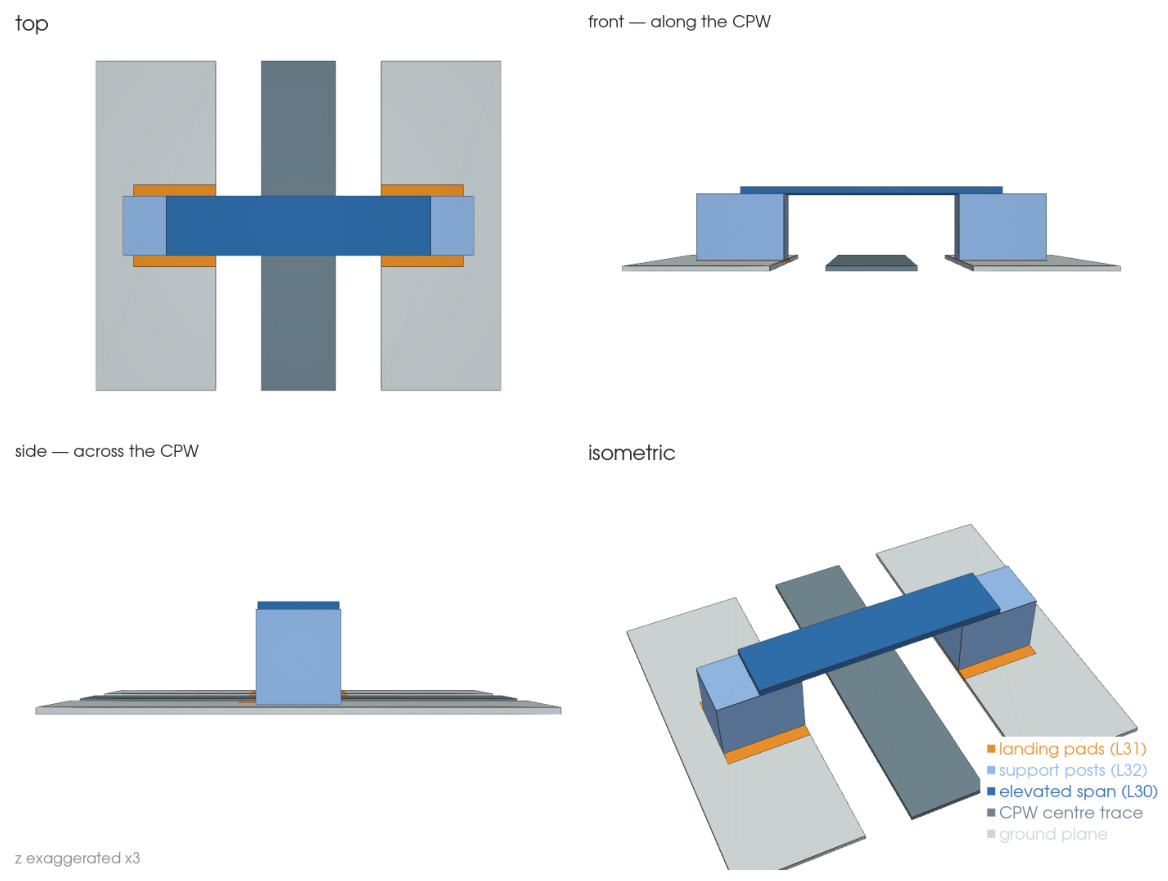

In [ ]:
# Real 3D render of the airbridge with PyVista (VTK) — a true depth-sorted
# renderer, unlike matplotlib's mplot3d (which has no real occlusion and makes
# overlapping/elevated parts look wrong). Every x/y extent is read from the real
# Airbridge QGeometry + CPW parameters; only z is exaggerated (x3) so the ~3 µm
# bridge is visible next to a ~40 µm span. Four views make the shape unambiguous.
#
# Needs ``pip install pyvista`` and an OpenGL backend (a display, EGL, OSMesa, or
# a headless Xvfb). The tutorial ships the rendered image; run the cell yourself
# (with the deps above) to spin it around live.
try:
    import pyvista as pv
    from qiskit_metal.designs.design_multiplanar import MultiPlanar
    from qiskit_metal.qlibrary.tlines.airbridge import Airbridge

    # One airbridge with support posts, at the origin. Native frame: the span
    # crosses along x, so the CPW it hops runs along y.
    _d = MultiPlanar()
    _d.overwrite_enabled = True
    _ab = Airbridge(_d, "ab", options=dict(enable_posts="True"))
    _d.rebuild()
    _p = _ab.parse_options()

    PAD_T, POST_TOP, SPAN_T = 0.2, 3.0, 0.3
    ZEX = 3.0  # z exaggeration (true bridge ~3 µm over a ~40 µm span)
    _w = _d.parse_value("10um") * 1e3
    _g = _d.parse_value("6um") * 1e3
    _Y = (2 * _p.pad_length + _p.crossover_length) * 1e3
    _GND = _w / 2 + _g + 16

    def _box(x0, x1, y0, y1, z0, z1):
        return pv.Box(bounds=(x0, x1, y0, y1, z0 * ZEX, z1 * ZEX))

    _meshes = [
        (_box(-_w / 2, _w / 2, -_Y / 2, _Y / 2, 0, PAD_T), "#6E8494"),  # CPW trace
        (_box(_w / 2 + _g, _GND, -_Y / 2, _Y / 2, 0, PAD_T), "#CBD5DD"),  # ground far
        (
            _box(-_GND, -(_w / 2 + _g), -_Y / 2, _Y / 2, 0, PAD_T),
            "#CBD5DD",
        ),  # ground near
    ]
    _cols = {
        31: (0, PAD_T, "#E8912B"),  # landing pads
        32: (PAD_T, POST_TOP, "#8FB8EC"),  # support posts
        30: (POST_TOP, POST_TOP + SPAN_T, "#2F6FB2"),
    }  # elevated span
    _ordr = {31: 0, 32: 1, 30: 2}
    for _, _row in sorted(
        _ab.qgeometry_table("poly").iterrows(), key=lambda r: _ordr[int(r[1]["layer"])]
    ):
        _z0, _z1, _c = _cols[int(_row["layer"])]
        _x0, _y0, _x1, _y1 = (v * 1e3 for v in _row["geometry"].bounds)
        _meshes.append((_box(_x0, _x1, _y0, _y1, _z0, _z1), _c))

    pl = pv.Plotter(
        off_screen=True, shape=(2, 2), window_size=(1400, 1050), border=False
    )

    def _populate():
        for _m, _c in _meshes:
            pl.add_mesh(
                _m,
                color=_c,
                show_edges=True,
                edge_color="#333333",
                line_width=1,
                ambient=0.35,
                diffuse=0.7,
                specular=0.15,
            )
        pl.set_background("white")

    _titles = ["top", "front — along the CPW", "side — across the CPW", "isometric"]
    _setters = ["view_xy", "view_xz", "view_yz", "view_isometric"]
    for _i, (_r, _cc) in enumerate([(0, 0), (0, 1), (1, 0), (1, 1)]):
        pl.subplot(_r, _cc)
        _populate()
        getattr(pl, _setters[_i])()
        if _setters[_i] == "view_isometric":
            pl.camera.azimuth = 20
            pl.camera.elevation = 12
            pl.add_legend(
                labels=[
                    ["landing pads (L31)", "#E8912B"],
                    ["support posts (L32)", "#8FB8EC"],
                    ["elevated span (L30)", "#2F6FB2"],
                    ["CPW centre trace", "#6E8494"],
                    ["ground plane", "#CBD5DD"],
                ],
                bcolor="white",
                size=(0.32, 0.26),
                loc="lower right",
                face="r",
            )
        pl.add_text(_titles[_i], position="upper_left", font_size=11, color="#222222")
        pl.camera.zoom(1.6 if _setters[_i] == "view_yz" else 1.3)
    pl.subplot(1, 0)
    pl.add_text("z exaggerated x3", position="lower_left", font_size=9, color="#888888")

    _img = pl.screenshot(return_img=True)
    pl.close()
    fig, _axp = plt.subplots(figsize=(13, 9.7))
    _axp.imshow(_img)
    _axp.axis("off")
    fig
except Exception as _exc:  # pragma: no cover - depends on optional pyvista + GL
    print("PyVista 3D render unavailable:", _exc)
    print(
        "Install it with `pip install pyvista` and ensure an OpenGL/OSMesa/Xvfb backend,"
    )
    print("then re-run this cell to render the airbridge in true 3D.")

### A whole row, in 3D

And the payoff: `route_airbridges` drops a bridge every `pitch` along the
trace, so a real device is crossed by a *row* of these elevated spans tying
the ground plane together. Here is that CPW rendered in true 3D:

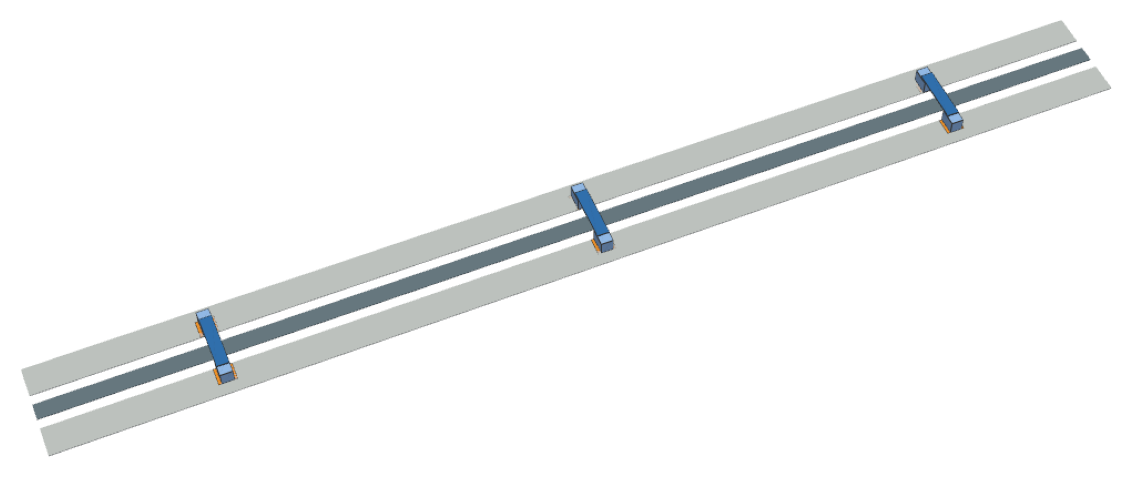

In [ ]:
# The whole story in 3D: a CPW crossed by a row of airbridges, each an elevated
# span on two support posts tying the ground planes together. Rendered with
# PyVista (VTK) from the real auto-placed geometry (route_airbridges +
# apply_airbridge_layer_stack); z is exaggerated x3 for visibility. Needs
# `pip install pyvista` and an OpenGL backend — the tutorial ships the image.
try:
    import pyvista as pv
    from qiskit_metal import Dict
    from qiskit_metal.designs.design_multiplanar import MultiPlanar
    from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
    from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight
    from qiskit_metal.qlibrary.tlines.airbridge import (
        Airbridge,
        route_airbridges,
        apply_airbridge_layer_stack,
    )

    _hd = MultiPlanar()
    _hd.overwrite_enabled = True
    OpenToGround(_hd, "A", options=dict(pos_x="-0.32mm", orientation="0"))
    OpenToGround(_hd, "B", options=dict(pos_x="0.32mm", orientation="180"))
    _hcpw = RouteStraight(
        _hd,
        "cpw",
        options=Dict(
            pin_inputs=Dict(
                start_pin=Dict(component="A", pin="open"),
                end_pin=Dict(component="B", pin="open"),
            ),
            trace_width="10um",
            trace_gap="6um",
        ),
    )
    _hd.rebuild()
    route_airbridges(_hd, _hcpw, pitch="0.22mm", min_spacing="30um", enable_posts=True)
    _hd.rebuild()
    apply_airbridge_layer_stack(_hd, bridge_z_coord="3um", include_posts=True)

    PAD_T, POST_TOP, SPAN_T, ZEX = 0.2, 3.0, 0.3, 3.0
    _hcol = {31: "#E8912B", 32: "#8FB8EC", 30: "#2F6FB2"}
    _hzb = {31: (0, PAD_T), 32: (PAD_T, POST_TOP), 30: (POST_TOP, POST_TOP + SPAN_T)}
    _hord = {31: 0, 32: 1, 30: 2}

    def _hbox(x0, x1, y0, y1, z0, z1):
        return pv.Box(bounds=(x0, x1, y0, y1, z0 * ZEX, z1 * ZEX))

    hpl = pv.Plotter(off_screen=True, window_size=(1400, 620), border=False)
    hpl.set_background("white")
    _L, _w, _g = 640, 10.0, 6.0
    hpl.add_mesh(_hbox(-_L / 2, _L / 2, -_w / 2, _w / 2, 0, PAD_T), color="#6E8494")
    for _lo, _hi in [
        (_w / 2 + _g, _w / 2 + _g + 18),
        (-(_w / 2 + _g + 18), -(_w / 2 + _g)),
    ]:
        hpl.add_mesh(_hbox(-_L / 2, _L / 2, _lo, _hi, 0, PAD_T), color="#CBD5DD")
    _hrows = []
    for _cn, _c in _hd.components.items():
        if isinstance(_c, Airbridge):
            for _, _r in _c.qgeometry_table("poly").iterrows():
                _hrows.append((int(_r["layer"]), _r["geometry"].bounds))
    for _layer, _b in sorted(_hrows, key=lambda r: _hord[r[0]]):
        _z0, _z1 = _hzb[_layer]
        _x0, _y0, _x1, _y1 = (v * 1e3 for v in _b)
        hpl.add_mesh(
            _hbox(_x0, _x1, _y0, _y1, _z0, _z1),
            color=_hcol[_layer],
            show_edges=True,
            edge_color="#333333",
            line_width=1,
            ambient=0.35,
            diffuse=0.72,
            specular=0.15,
        )
    hpl.enable_depth_peeling()
    hpl.view_isometric()
    hpl.camera.azimuth = 22
    hpl.camera.elevation = 18
    hpl.camera.zoom(1.7)
    _himg = hpl.screenshot(return_img=True)
    hpl.close()
    # crop the surrounding white so the strip fills the frame
    _mask = (_himg < 250).any(axis=2)
    _ys, _xs = _mask.any(axis=1), _mask.any(axis=0)
    _y0, _y1 = _ys.argmax(), len(_ys) - _ys[::-1].argmax()
    _x0, _x1 = _xs.argmax(), len(_xs) - _xs[::-1].argmax()
    _himg = _himg[max(_y0 - 8, 0) : _y1 + 8, max(_x0 - 8, 0) : _x1 + 8]
    fig, _hax = plt.subplots(figsize=(12, 12 * _himg.shape[0] / _himg.shape[1]))
    _hax.imshow(_himg)
    _hax.axis("off")
    fig
except Exception as _exc:  # pragma: no cover - optional pyvista + GL
    print("PyVista 3D render unavailable:", _exc)
    print(
        "Install `pip install pyvista` with an OpenGL/OSMesa/Xvfb backend to render it."
    )

That's the airbridge workflow: place them (individually or automatically),
see them in `qm.view`, and export. Design-of-record and roadmap (including the
experimental 3D/Ansys span) are tracked in issue #1138.